# LNG Boil-Off Gas (BOG) Management

This notebook demonstrates simulation of LNG boil-off gas during ship transport
using NeqSim's LNG ship model. We cover:

1. **BOG rate calculation** during LNG storage and transport
2. **LNG ageing** — compositional changes over time as lighter components preferentially evaporate
3. **BOG reliquefaction** — process design for re-condensing boil-off gas
4. **Impact on LNG quality** — tracking changes to heating value and Wobbe index

## Background

LNG is stored at approximately -162°C and 1 bara. Heat leakage through tank insulation
causes continuous evaporation (boil-off). Typical BOG rates are 0.10–0.15% of cargo
volume per day for modern membrane tanks.

The boil-off gas is enriched in nitrogen and methane (the most volatile components),
which changes the remaining LNG composition over time ("LNG ageing"). This affects
the heating value, density, and Wobbe index of the delivered LNG.

In [1]:
# Setup NeqSim
import subprocess, sys
try:
    from neqsim import jneqsim
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'neqsim'])
    from neqsim import jneqsim

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# NeqSim Java classes
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Separator = jneqsim.process.equipment.separator.Separator
Mixer = jneqsim.process.equipment.mixer.Mixer
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

print('NeqSim loaded successfully')

NeqSim loaded successfully


## 1. LNG Composition and Initial Properties

We start by defining a typical lean LNG composition and calculating its properties
at storage conditions.

In [2]:
# Define LNG compositions (two typical grades)
compositions = {
    'Lean LNG (Qatar)': {'nitrogen': 0.1, 'methane': 91.5, 'ethane': 5.5, 'propane': 2.0, 'i-butane': 0.5, 'n-butane': 0.4},
    'Rich LNG (Nigeria)': {'nitrogen': 0.05, 'methane': 87.0, 'ethane': 7.0, 'propane': 3.5, 'i-butane': 1.2, 'n-butane': 1.25}
}

for name, comp in compositions.items():
    lng = SystemSrkEos(273.15 - 162.0, 1.05)
    for component, fraction in comp.items():
        lng.addComponent(component, fraction)
    lng.setMixingRule('classic')

    ops = ThermodynamicOperations(lng)
    ops.TPflash()
    lng.initProperties()

    print(f'\n=== {name} ===')
    print(f'Temperature:    {lng.getTemperature() - 273.15:.1f} °C')
    print(f'Pressure:       {lng.getPressure("bara"):.2f} bara')
    print(f'Density:        {lng.getDensity("kg/m3"):.1f} kg/m³')
    print(f'Molar Mass:     {lng.getMolarMass("kg/mol") * 1000:.2f} g/mol')
    print(f'Num Phases:     {lng.getNumberOfPhases()}')


=== Lean LNG (Qatar) ===
Temperature:    -162.0 °C
Pressure:       1.05 bara
Density:        462.9 kg/m³
Molar Mass:     17.77 g/mol
Num Phases:     1

=== Rich LNG (Nigeria) ===
Temperature:    -162.0 °C
Pressure:       1.05 bara
Density:        483.9 kg/m³
Molar Mass:     19.04 g/mol
Num Phases:     1


## 2. LNG Ship BOG Simulation

We use NeqSim's `LNGship` class to simulate boil-off during a typical voyage
(e.g., Qatar to Europe, ~10 days transit). The model tracks:
- Temperature evolution
- Composition changes (LNG ageing)
- Heating value (GCV) and Wobbe Index changes

In [3]:
import jpype
LNGship = jpype.JClass('neqsim.fluidmechanics.flowsystem.twophaseflowsystem.shipsystem.LNGship')

# Define LNG cargo
lng_cargo = SystemSrkEos(273.15 - 162.0, 1.05)
lng_cargo.addComponent('nitrogen', 0.1)
lng_cargo.addComponent('methane', 91.5)
lng_cargo.addComponent('ethane', 5.5)
lng_cargo.addComponent('propane', 2.0)
lng_cargo.addComponent('i-butane', 0.5)
lng_cargo.addComponent('n-butane', 0.4)
lng_cargo.setMixingRule('classic')

# Create LNG ship model
# Parameters: thermoSystem, tankVolume (m³), dailyBoilOffRatio (%/day as fraction)
tank_volume = 170000.0  # m³ (Q-Max carrier)
daily_bor = 0.001  # 0.10% per day (modern membrane tank)

ship = LNGship(lng_cargo, tank_volume, daily_bor)
# Use public field for number of timesteps (note the 'off' spelling)
ship.numberOffTimeSteps = 100
# Use setEndTime method for voyage duration (hours)
ship.setEndTime(24.0 * 15)  # 15 days voyage
ship.createSystem()
ship.solveSteadyState(0, None)
ship.solveTransient(0, None)

# Extract results from public arrays
print(f'Simulation completed: {ship.numberOffTimeSteps} timesteps')
print(f'Initial volume:  {ship.totalTankVolume:.0f} m³')
print(f'End volume:      {ship.endVolume:.0f} m³')
print(f'Daily BOG vol:   {ship.dailyBoilOffVolume:.0f} m³/day')
print(f'\nTank temperatures and volumes at key timesteps:')
for i in [0, 25, 50, 75, 99]:
    if i < len(ship.tankTemperature):
        print(f'  Step {i:3d}: T = {ship.tankTemperature[i]:.2f} K, V = {ship.volume[i]:.0f} m³')

Simulation completed: 100 timesteps
Initial volume:  170000 m³
End volume:      167450 m³
Daily BOG vol:   170 m³/day

Tank temperatures and volumes at key timesteps:
  Step   0: T = 113.06 K, V = 170000 m³
  Step  25: T = 113.11 K, V = 169358 m³
  Step  50: T = 113.15 K, V = 168715 m³
  Step  75: T = 113.18 K, V = 168070 m³
  Step  99: T = 113.21 K, V = 167450 m³


## 3. BOG Rate Sensitivity Analysis

We study how the daily boil-off rate affects LNG quality changes over a voyage.

Warning for BOR=0.0005: 'neqsim.fluidmechanics.flowsystem.twophaseflowsystem.shipsystem.LNGship' object has no attribute 'xmethane'
Warning for BOR=0.001: 'neqsim.fluidmechanics.flowsystem.twophaseflowsystem.shipsystem.LNGship' object has no attribute 'xmethane'
Warning for BOR=0.0015: 'neqsim.fluidmechanics.flowsystem.twophaseflowsystem.shipsystem.LNGship' object has no attribute 'xmethane'
Warning for BOR=0.002: 'neqsim.fluidmechanics.flowsystem.twophaseflowsystem.shipsystem.LNGship' object has no attribute 'xmethane'


C:\Users\ESOL\AppData\Local\Temp\ipykernel_13480\139570334.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend()
C:\Users\ESOL\AppData\Local\Temp\ipykernel_13480\139570334.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 1].legend()
C:\Users\ESOL\AppData\Local\Temp\ipykernel_13480\139570334.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 0].legend()
C:\Users\ESOL\AppData\Local\Temp\ipykernel_13480\139570334.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no 

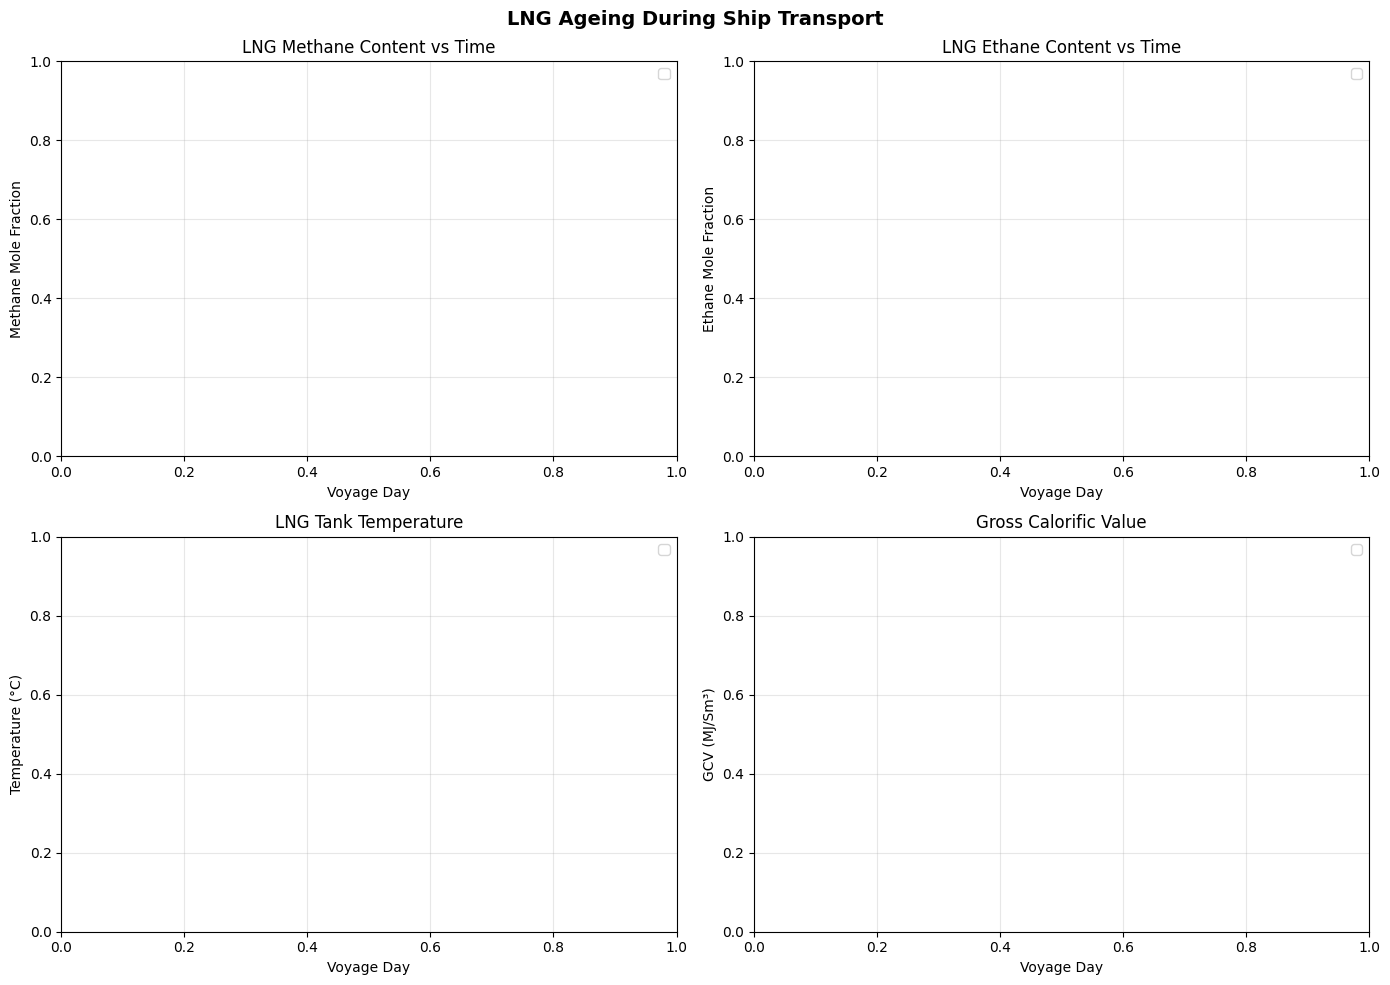

Figure saved: lng_bog_sensitivity.png


In [5]:
# Simulate BOG for different daily boil-off rates
bor_values = [0.0005, 0.001, 0.0015, 0.002]  # 0.05% to 0.20% per day
voyage_days = 20

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for bor in bor_values:
    # Create fresh LNG fluid for each simulation
    lng_sim = SystemSrkEos(273.15 - 162.0, 1.05)
    lng_sim.addComponent('nitrogen', 0.1)
    lng_sim.addComponent('methane', 91.5)
    lng_sim.addComponent('ethane', 5.5)
    lng_sim.addComponent('propane', 2.0)
    lng_sim.addComponent('i-butane', 0.5)
    lng_sim.addComponent('n-butane', 0.4)
    lng_sim.setMixingRule('classic')

    ship_sim = LNGship(lng_sim, 170000.0, bor)
    ship_sim.numberOffTimeSteps = 80  # public field
    ship_sim.setEndTime(24.0 * voyage_days)
    ship_sim.createSystem()
    ship_sim.solveSteadyState(0, None)
    ship_sim.solveTransient(0, None)

    # Get profiles from public arrays
    try:
        x_methane = list(ship_sim.xmethane) if ship_sim.xmethane else []
        x_ethane = list(ship_sim.xethane) if ship_sim.xethane else []
        temps = list(ship_sim.tankTemperature) if ship_sim.tankTemperature else []
        gcv_vals = list(ship_sim.GCV) if ship_sim.GCV else []

        days = np.linspace(0, voyage_days, len(x_methane)) if x_methane else []

        label = f'BOR={bor*100:.2f}%/day'
        if len(x_methane) > 0:
            axes[0, 0].plot(days, x_methane, label=label)
        if len(x_ethane) > 0:
            axes[0, 1].plot(days, x_ethane, label=label)
        if len(temps) > 0:
            temps_c = [t - 273.15 if t > 0 else t for t in temps]
            axes[1, 0].plot(days, temps_c, label=label)
        if len(gcv_vals) > 0:
            axes[1, 1].plot(days, gcv_vals, label=label)
    except Exception as e:
        print(f'Warning for BOR={bor}: {e}')

axes[0, 0].set_xlabel('Voyage Day')
axes[0, 0].set_ylabel('Methane Mole Fraction')
axes[0, 0].set_title('LNG Methane Content vs Time')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].set_xlabel('Voyage Day')
axes[0, 1].set_ylabel('Ethane Mole Fraction')
axes[0, 1].set_title('LNG Ethane Content vs Time')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].set_xlabel('Voyage Day')
axes[1, 0].set_ylabel('Temperature (°C)')
axes[1, 0].set_title('LNG Tank Temperature')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].set_xlabel('Voyage Day')
axes[1, 1].set_ylabel('GCV (MJ/Sm³)')
axes[1, 1].set_title('Gross Calorific Value')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle('LNG Ageing During Ship Transport', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lng_bog_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: lng_bog_sensitivity.png')

## 4. BOG Reliquefaction Process

On modern LNG carriers, BOG can be reliquefied instead of burning it as fuel.
A typical reliquefaction system consists of:

1. BOG compressor (from 1 bara to ~6 bara)
2. BOG aftercooler (seawater cooling to ~25°C)
3. Further cooling using nitrogen expander or cascade cycle
4. JT expansion and return to tank

Here we simulate a simple BOG reliquefaction using compression, cooling, and JT expansion.

In [ ]:
# BOG Reliquefaction Process
# BOG composition (enriched in methane/nitrogen)
bog_fluid = SystemSrkEos(273.15 - 155.0, 1.05)
bog_fluid.addComponent('nitrogen', 1.5)  # Enriched due to preferential evaporation
bog_fluid.addComponent('methane', 96.0)
bog_fluid.addComponent('ethane', 2.0)
bog_fluid.addComponent('propane', 0.5)
bog_fluid.setMixingRule('classic')

bog_stream = Stream('BOG', bog_fluid)
bog_stream.setFlowRate(5000.0, 'kg/hr')  # Typical BOG rate
bog_stream.setTemperature(-155.0, 'C')
bog_stream.setPressure(1.05, 'bara')

# Build reliquefaction process
reliq_process = ProcessSystem()
reliq_process.add(bog_stream)

# Stage 1: Compress BOG
bog_comp1 = Compressor('BOG Comp 1', bog_stream)
bog_comp1.setOutletPressure(4.0)
bog_comp1.setIsentropicEfficiency(0.75)
reliq_process.add(bog_comp1)

# Intercooler
bog_ic = Cooler('BOG IC', bog_comp1.getOutletStream())
bog_ic.setOutTemperature(273.15 + 25.0)
reliq_process.add(bog_ic)

# Stage 2: Compress further
bog_comp2 = Compressor('BOG Comp 2', bog_ic.getOutletStream())
bog_comp2.setOutletPressure(40.0)
bog_comp2.setIsentropicEfficiency(0.75)
reliq_process.add(bog_comp2)

# Aftercooler
bog_ac = Cooler('BOG AC', bog_comp2.getOutletStream())
bog_ac.setOutTemperature(273.15 + 25.0)
reliq_process.add(bog_ac)

# Pre-cool using cold BOG (simulate as cooler)
bog_precool = Cooler('BOG Precool', bog_ac.getOutletStream())
bog_precool.setOutTemperature(273.15 - 80.0)
reliq_process.add(bog_precool)

# JT expansion back to tank pressure
bog_jt = ThrottlingValve('BOG JT', bog_precool.getOutletStream())
bog_jt.setOutletPressure(1.1)
reliq_process.add(bog_jt)

# Separator to separate liquid (return to tank) from flash gas
bog_sep = Separator('BOG Sep', bog_jt.getOutletStream())
reliq_process.add(bog_sep)

reliq_process.run()

print('=== BOG Reliquefaction Results ===')
print(f'BOG Feed Rate:           {bog_stream.getFlowRate("kg/hr"):.0f} kg/hr')
print(f'BOG Feed Temperature:    {bog_stream.getTemperature() - 273.15:.1f} °C')
print()
print(f'After Comp 1:            {bog_comp1.getOutletStream().getTemperature() - 273.15:.1f} °C')
print(f'After Comp 2:            {bog_comp2.getOutletStream().getTemperature() - 273.15:.1f} °C')
print(f'After JT (tank return):  {bog_jt.getOutletStream().getTemperature() - 273.15:.1f} °C')
print()
comp_power = bog_comp1.getPower('kW') + bog_comp2.getPower('kW')
print(f'Comp 1 Power:            {bog_comp1.getPower("kW"):.0f} kW')
print(f'Comp 2 Power:            {bog_comp2.getPower("kW"):.0f} kW')
print(f'Total Compression Power: {comp_power:.0f} kW')
print(f'Specific Power:          {comp_power / 5000.0:.3f} kWh/kg BOG')
print()
liq_rate = bog_sep.getLiquidOutStream().getFlowRate('kg/hr')
gas_rate = bog_sep.getGasOutStream().getFlowRate('kg/hr')
print(f'Liquid returned to tank: {liq_rate:.0f} kg/hr')
print(f'Flash gas (fuel):        {gas_rate:.0f} kg/hr')
print(f'Liquefaction ratio:      {liq_rate / 5000.0 * 100:.1f}%')

## 5. BOG Composition Comparison

Compare BOG vs remaining LNG composition to visualize the preferential evaporation effect.

In [ ]:
# Flash at storage conditions to get vapor (BOG) and liquid (LNG) compositions
lng_flash = SystemSrkEos(273.15 - 160.0, 1.05)
lng_flash.addComponent('nitrogen', 0.1)
lng_flash.addComponent('methane', 91.5)
lng_flash.addComponent('ethane', 5.5)
lng_flash.addComponent('propane', 2.0)
lng_flash.addComponent('i-butane', 0.5)
lng_flash.addComponent('n-butane', 0.4)
lng_flash.setMixingRule('classic')

ops_flash = ThermodynamicOperations(lng_flash)
ops_flash.TPflash()
lng_flash.initProperties()

components = ['nitrogen', 'methane', 'ethane', 'propane', 'i-butane', 'n-butane']
feed_comp = [0.1, 91.5, 5.5, 2.0, 0.5, 0.4]

# Get vapor and liquid compositions
nphases = int(lng_flash.getNumberOfPhases())
ncomp = len(components)

liq_comp = []
vap_comp = []
for i in range(ncomp):
    if nphases >= 2:
        vap_comp.append(float(lng_flash.getPhase(0).getComponent(i).getx()) * 100)
        liq_comp.append(float(lng_flash.getPhase(1).getComponent(i).getx()) * 100)
    else:
        vap_comp.append(feed_comp[i])
        liq_comp.append(feed_comp[i])

# Create comparison table
comp_df = pd.DataFrame({
    'Component': components,
    'Feed (mol%)': feed_comp,
    'BOG/Vapor (mol%)': [round(v, 3) for v in vap_comp],
    'LNG/Liquid (mol%)': [round(l, 3) for l in liq_comp]
})
print(comp_df.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(components))
width = 0.25

bars1 = ax.bar(x - width, feed_comp, width, label='Feed', color='#2ca02c')
bars2 = ax.bar(x, vap_comp, width, label='BOG (Vapor)', color='#ff7f0e')
bars3 = ax.bar(x + width, liq_comp, width, label='LNG (Liquid)', color='#1f77b4')

ax.set_xlabel('Component', fontsize=12)
ax.set_ylabel('Mole Fraction (%)', fontsize=12)
ax.set_title('Feed vs BOG vs Remaining LNG Composition', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(components)
ax.legend()
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('bog_composition_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: bog_composition_comparison.png')

## Summary

This notebook demonstrated:

- **LNG ship BOG simulation** using NeqSim's transient LNG model
- **LNG ageing effects** — methane preferentially evaporates, enriching heavier components in remaining LNG
- **BOG reliquefaction** — compression, cooling, and JT expansion to return BOG to liquid
- **Composition analysis** — quantified differences between BOG and LNG compositions

### Key Takeaways
- Modern membrane tanks achieve BOR of ~0.10%/day
- LNG heating value increases during voyage (heavier components remain)
- BOG is enriched in N₂ and CH₄ compared to bulk LNG
- Reliquefaction reduces cargo loss but requires significant compression power

### Next Steps
- Model BOG as fuel for ship propulsion (DFDE, X-DF engines)
- Optimize reliquefaction cycle for minimum power
- Study effect of tank filling level on BOG rate
- Compare nitrogen as cooldown medium vs. LNG spray cooling